In [13]:
import codes.utils.tools.network_tool as network_tool
import codes.utils.configs.city_clusters_config as city_clusters
import codes.plots.network_plots as network_plots

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import importlib

In [38]:
importlib.reload(network_tool)
importlib.reload(city_clusters)
importlib.reload(network_plots)

<module 'codes.plots.network_plots' from '/Volumes/EDisk/gitRepo/global-evcs-2024/codes/plots/network_plots.py'>

In [36]:
''' Load dataset '''
cn_dataset = network_plots.load_dataset(region='china',
                            radius_list=[300, 800, 1000],
                            )
us_dataset = network_plots.load_dataset(region='usa',
                            radius_list=[300, 800, 1000],
                            )
'''Add HASC_2 to the us_dataset'''
us_city_bound = gpd.read_file(r"data/input/boundary/usa/gadm41_USA_2.shp",
                                include_fields=['NAME_1', 'NAME_2', 'HASC_2'])
us_dataset = {r: pd.merge(us_dataset.get(r),
                            us_city_bound,
                            on=['NAME_1', 'NAME_2'],
                            how='left')
                for r in list(us_dataset.keys())}
eu_dataset = network_plots.load_dataset(region='eu',
                            radius_list=[300, 800, 1000],
                            )

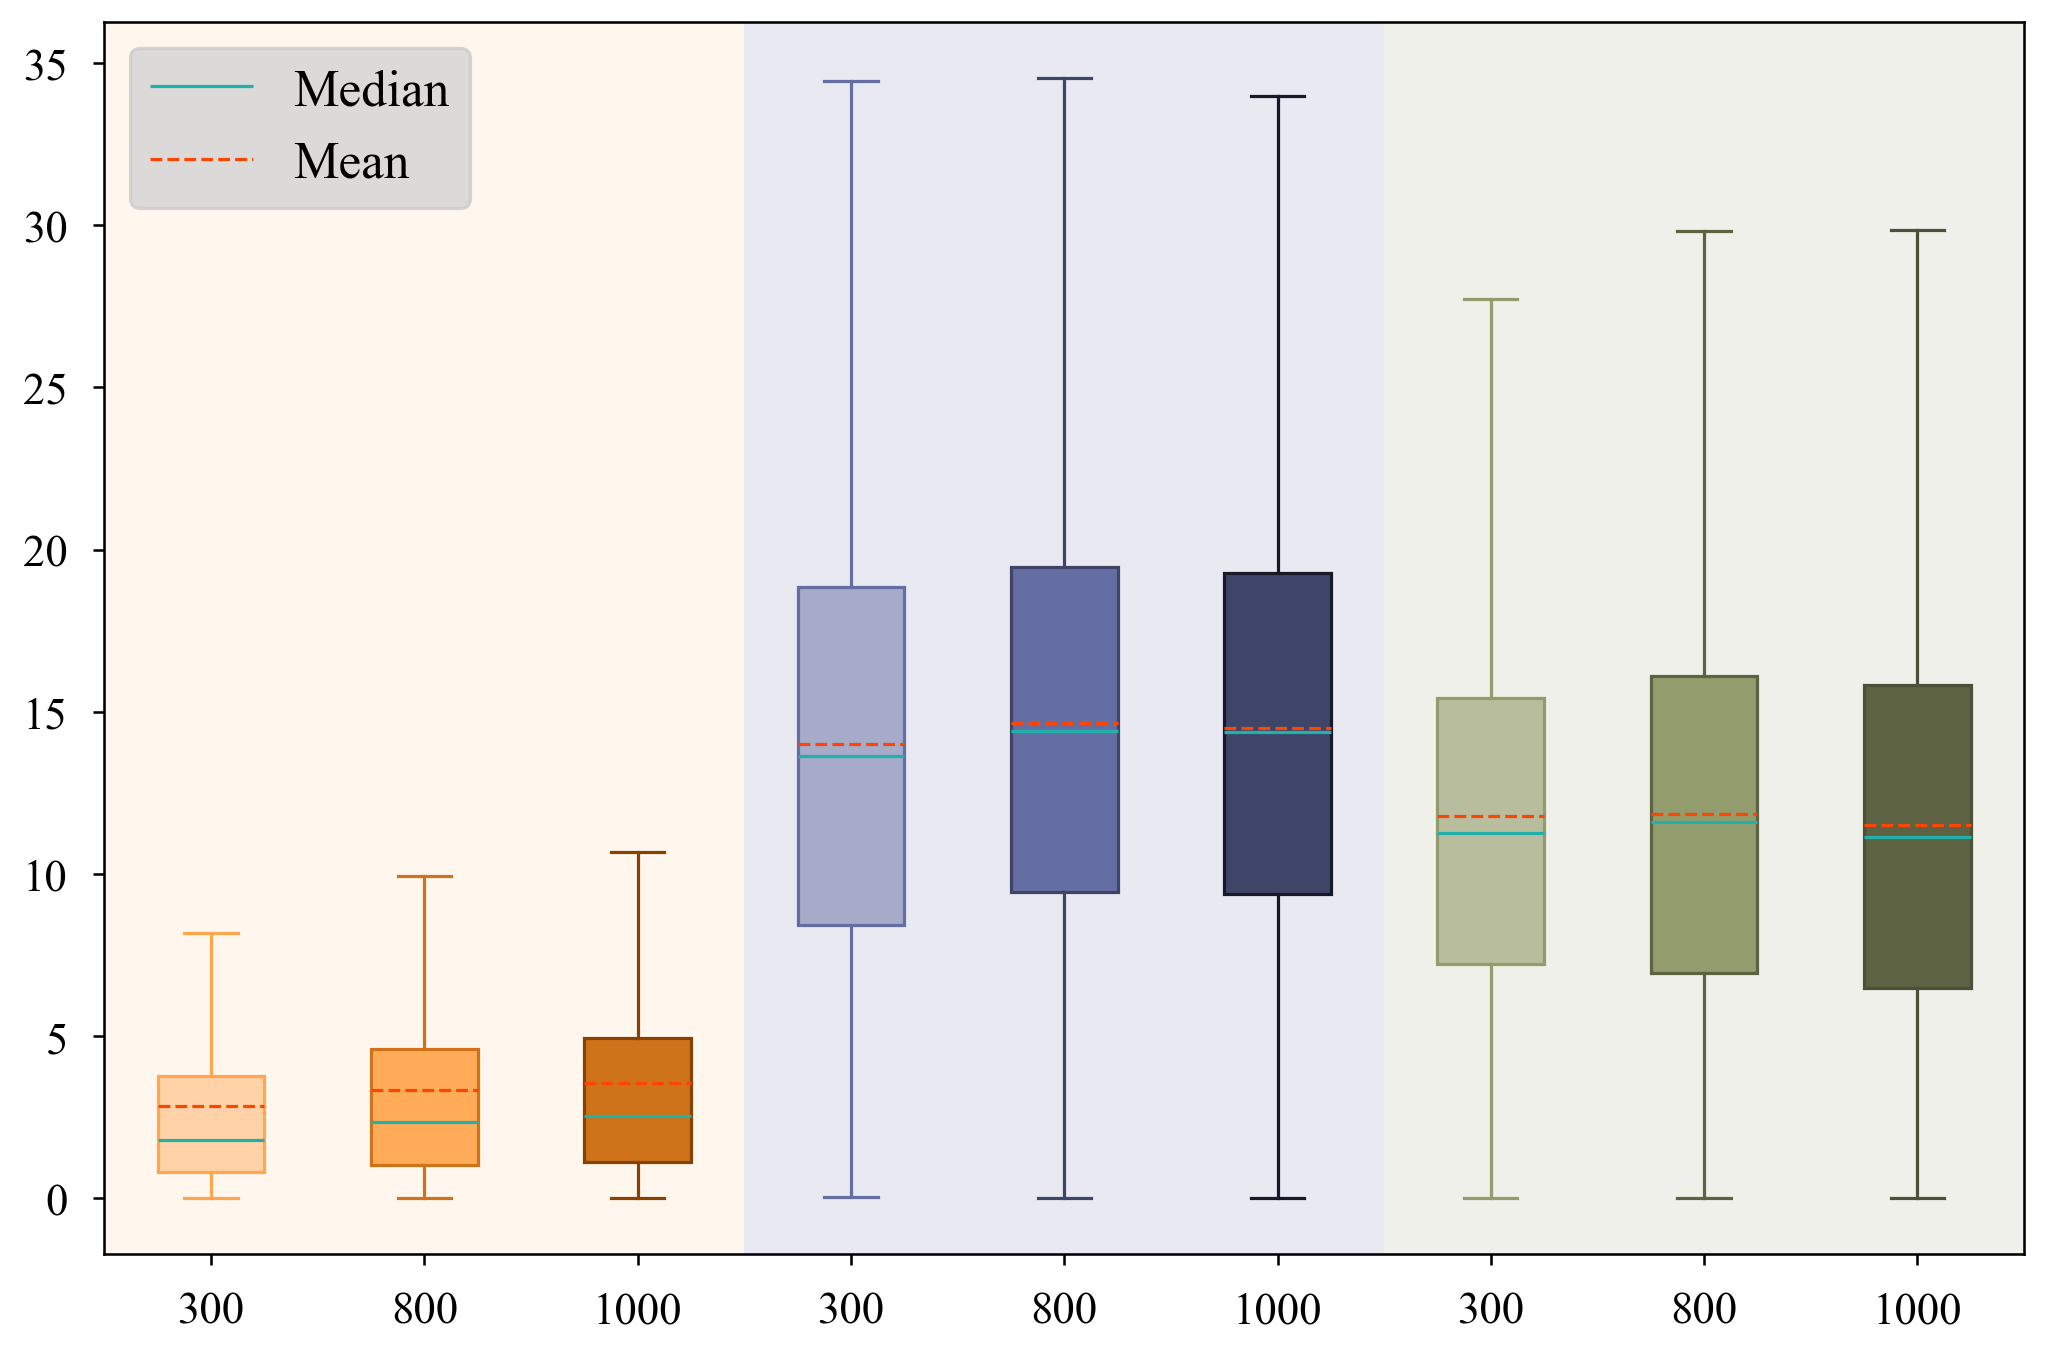

In [37]:
network_plots.plot_network_comparison(cn_data=cn_dataset,
                        us_data=us_dataset,
                        eu_data=eu_dataset,
                        
                        )

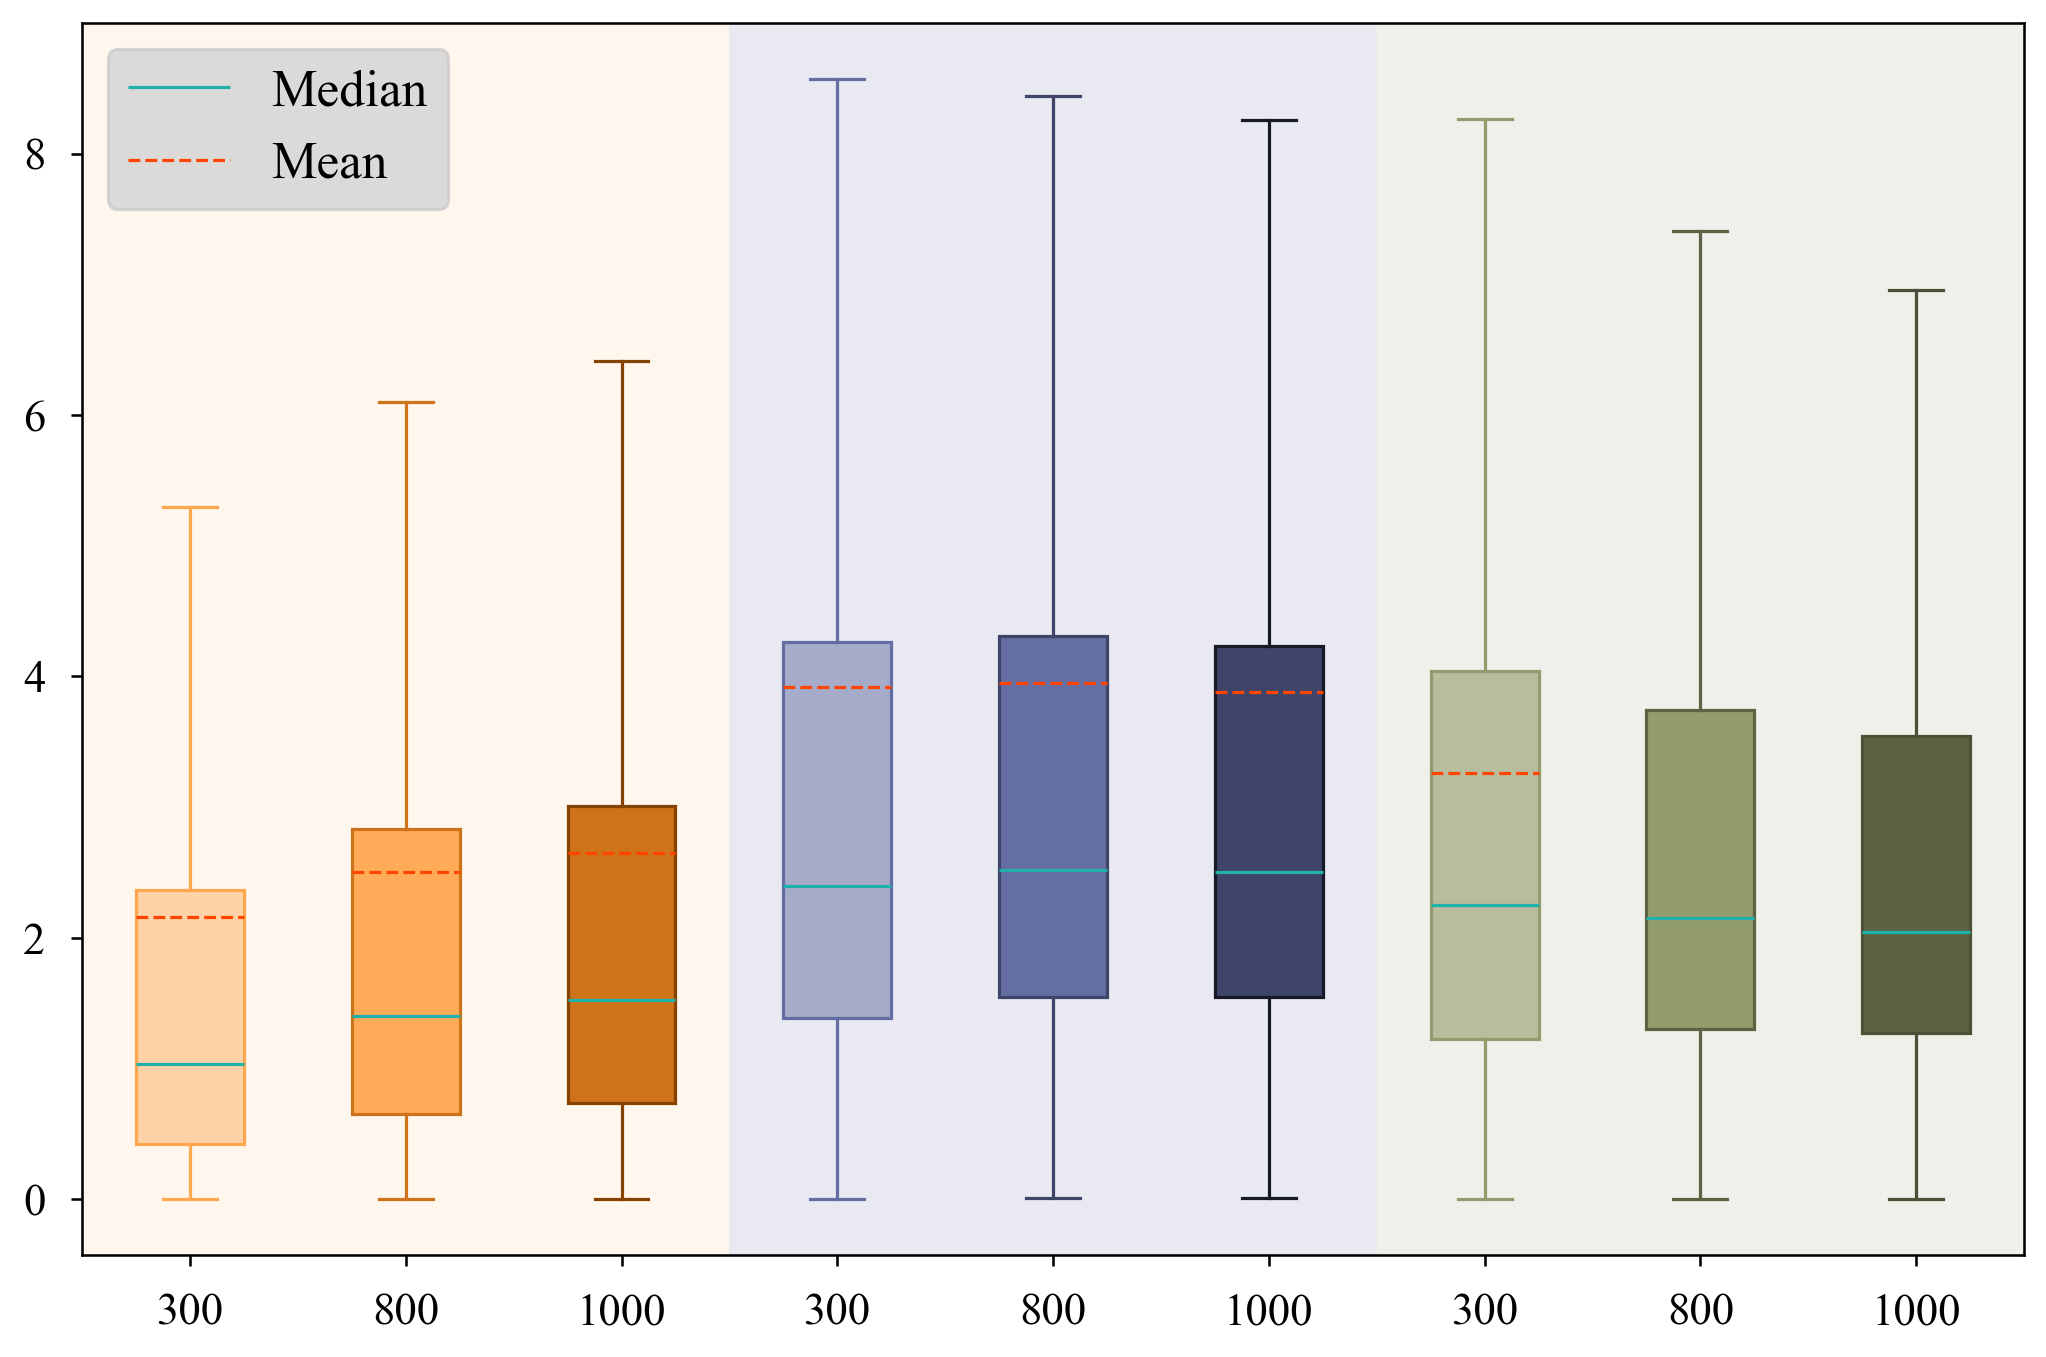

In [39]:
network_plots.plot_network_ratio_comparison(cn_data=cn_dataset,
                        us_data=us_dataset,
                        eu_data=eu_dataset,
                        )